# Compare DD Models To TT Ground Truth

This notebook compares data-driven models against a task-trained reference using the CtD `Comparison` API.

It combines:
- classic metrics already used in the repo: `state_r2`, `rate_r2`, `co-bps`, `cycle_con`
- new geometry metrics: `wasserstein_geometry`, `kl_geometry`

## What the geometry metrics do

Both geometry metrics compare the validation distributions of ground-truth and inferred trajectories after mapping them into a common comparison space:
1. choose an input source such as `latents`, `rates`, or `spikes`
2. optionally apply PCA
3. optionally construct a delay embedding
4. fit a linear map from inferred train trajectories into the reference train space
5. compare the aligned validation distributions with either Gaussian Wasserstein distance or Gaussian KL divergence

For both `wasserstein_geometry` and `kl_geometry`, lower values mean the inferred model is geometrically closer to the task-trained ground truth.


## Setup

Edit the sweep path and model type in the configuration cell below if you want to evaluate a different DD sweep.


In [1]:
from ctd.comparison.analysis.tt.tt import Analysis_TT
from ctd.comparison.analysis.dd.dd import Analysis_DD
from ctd.comparison.comparison import Comparison

import dotenv
import os
import numpy as np
import matplotlib.pyplot as plt

dotenv.load_dotenv(override=True)
HOME_DIR = os.getenv("HOME_DIR")
print(HOME_DIR)


/home/csverst/Github/CtDBenchmark/


In [2]:
# Reference task-trained model
tt_path = HOME_DIR + "content/trained_models/task-trained/tt_3bff/"

# Data-driven sweep configuration
# Replace these with your own sweep path / group label / model type if needed.
MODEL_SWEEP_PATH = tt_path + "20250207_3BFF_NODE_sweep/"
MODEL_TYPE = "SAE"
MODEL_GROUP = "NODE"

print("TT path:", tt_path)
print("DD sweep path:", MODEL_SWEEP_PATH)


TT path: /home/csverst/Github/CtDBenchmark/content/trained_models/task-trained/tt_3bff/
DD sweep path: /home/csverst/Github/CtDBenchmark/content/trained_models/task-trained/tt_3bff/20250207_3BFF_NODE_sweep/


## Load the Reference TT Model

The task-trained model acts as the ground truth reference inside `Comparison`. All DD models are scored against this analysis object.


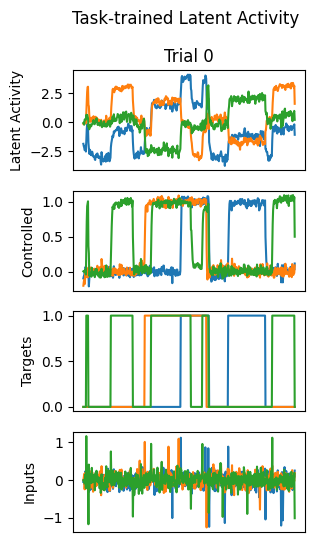

In [3]:
tt_analysis = Analysis_TT(run_name="tt_3bff", filepath=tt_path)
tt_analysis.plot_trial_io(num_trials=1)


## Load the DD Sweep

Each subfolder is assumed to encode a latent size in its name via `latent_size=...`.


In [4]:
subfolders = sorted([f.path for f in os.scandir(MODEL_SWEEP_PATH) if f.is_dir()])
print(f"Found {len(subfolders)} model folders")
subfolders[:3]


Found 30 model folders


['/home/csverst/Github/CtDBenchmark/content/trained_models/task-trained/tt_3bff/20250207_3BFF_NODE_sweep/prefix=tt_3bff_latent_size=16_max_epochs=1000_seed=0',
 '/home/csverst/Github/CtDBenchmark/content/trained_models/task-trained/tt_3bff/20250207_3BFF_NODE_sweep/prefix=tt_3bff_latent_size=16_max_epochs=1000_seed=1',
 '/home/csverst/Github/CtDBenchmark/content/trained_models/task-trained/tt_3bff/20250207_3BFF_NODE_sweep/prefix=tt_3bff_latent_size=16_max_epochs=1000_seed=2']

In [5]:
comparison = Comparison(comparison_tag="3BFF_combined_metrics")
comparison.load_analysis(tt_analysis, group="TT", reference_analysis=True)

lat_sizes = []
for subfolder in subfolders:
    subfolder = subfolder + "/"
    lat_size = int(subfolder.split("latent_size=")[1].split("_")[0])
    analysis = Analysis_DD.create(
        run_name=f"{MODEL_GROUP}_{lat_size}",
        filepath=subfolder,
        model_type=MODEL_TYPE,
    )
    comparison.load_analysis(analysis, group=MODEL_GROUP)
    lat_sizes.append(lat_size)
    print(f"Loaded {MODEL_GROUP}_{lat_size}")


Loaded NODE_16
Loaded NODE_16
Loaded NODE_16
Loaded NODE_16
Loaded NODE_16
Loaded NODE_32
Loaded NODE_32
Loaded NODE_32
Loaded NODE_32
Loaded NODE_32
Loaded NODE_3
Loaded NODE_3
Loaded NODE_3
Loaded NODE_3
Loaded NODE_3
Loaded NODE_5
Loaded NODE_5
Loaded NODE_5
Loaded NODE_5
Loaded NODE_5
Loaded NODE_64
Loaded NODE_64
Loaded NODE_64
Loaded NODE_64
Loaded NODE_64
Loaded NODE_8
Loaded NODE_8
Loaded NODE_8
Loaded NODE_8
Loaded NODE_8


## Metric Configuration

`classic_metric_dict_list` contains the original benchmark-style metrics.

`geometry_cfg` controls the common-space preprocessing used by both geometry metrics:
- `input_source`: typically `latents` for DD-vs-TT geometry comparisons
- `pca_dim`: optional PCA dimension before delay embedding
- `n_delays`, `delay_lag`: delay embedding hyperparameters
- `covariance_reg`: covariance regularization for numerical stability
- `random_state`: seed for any subsampling used by the metric


In [6]:
classic_metric_dict_list = {
    "state_r2": {},
    "rate_r2": {},
    "co-bps": {},
    "cycle_con": {"variance_threshold": 0.01},
}

geometry_cfg = {
    "input_source": "latents",
    "pca_dim": 16,
    "n_delays": 2,
    "delay_lag": 1,
    "covariance_reg": 1e-5,
    "random_state": 0,
}

combined_metric_dict_list = {
    **classic_metric_dict_list,
    "wasserstein_geometry": dict(geometry_cfg),
    "kl_geometry": dict(geometry_cfg),
}

combined_metric_dict_list


{'state_r2': {},
 'rate_r2': {},
 'co-bps': {},
 'cycle_con': {'variance_threshold': 0.01},
 'wasserstein_geometry': {'input_source': 'latents',
  'pca_dim': 16,
  'n_delays': 2,
  'delay_lag': 1,
  'covariance_reg': 1e-05,
  'random_state': 0},
 'kl_geometry': {'input_source': 'latents',
  'pca_dim': 16,
  'n_delays': 2,
  'delay_lag': 1,
  'covariance_reg': 1e-05,
  'random_state': 0}}

## Compute Metrics

This evaluates every DD model in the sweep against the TT reference.


In [7]:
metrics = comparison.compute_metrics(metric_dict_list=combined_metric_dict_list)



Working on 1 of 31: tt_3bff

Working on 2 of 31: NODE_16
State R2: 0.8482661247253418
Rate R2: 0.9092410206794739
CO-BPS: 0.12613725662231445
Cycle Consistency R2: 0.8683382272720337
Delay-Embed Wasserstein (latents): 0.6559236202878084
Delay-Embed Kl (latents): 1312.9941497482796

Working on 3 of 31: NODE_16
State R2: 0.7839089035987854
Rate R2: 0.9134836196899414
CO-BPS: 0.12678901851177216
Cycle Consistency R2: 0.7745678424835205
Delay-Embed Wasserstein (latents): 0.6400580914465495
Delay-Embed Kl (latents): 1301.490758668516

Working on 4 of 31: NODE_16
State R2: 0.8040499091148376
Rate R2: 0.9070491790771484
CO-BPS: 0.12586183845996857
Cycle Consistency R2: 0.8132787942886353
Delay-Embed Wasserstein (latents): 0.6368785083941374
Delay-Embed Kl (latents): 1510.5318311286203

Working on 5 of 31: NODE_16
State R2: 0.7535921335220337
Rate R2: 0.9140822291374207
CO-BPS: 0.12675130367279053
Cycle Consistency R2: 0.7496904134750366
Delay-Embed Wasserstein (latents): 0.683258638198582
De

In [8]:
lat_sizes = np.array(lat_sizes)
sort_idx = np.argsort(lat_sizes)
lat_sizes = lat_sizes[sort_idx]

metric_names = [
    "state_r2",
    "rate_r2",
    "co-bps",
    "cycle_con",
    "wasserstein_geometry",
    "kl_geometry",
]

for name in metric_names:
    metrics[name] = np.array(metrics[name])[sort_idx]

mean_metrics = {}
for name in metric_names:
    mean_metrics[name] = np.array([
        [lat, metrics[name][lat_sizes == lat].mean()]
        for lat in np.unique(lat_sizes)
    ])

summary_rows = []
for lat in np.unique(lat_sizes):
    row = {"latent_size": lat}
    for name in metric_names:
        row[name] = metrics[name][lat_sizes == lat].mean()
    summary_rows.append(row)

summary_rows[:3]


[{'latent_size': 3,
  'state_r2': 0.9666336297988891,
  'rate_r2': 0.8510551691055298,
  'co-bps': 0.1177485927939415,
  'cycle_con': 1.0,
  'wasserstein_geometry': 1.4407731470272056,
  'kl_geometry': 166123.65224301038},
 {'latent_size': 5,
  'state_r2': 0.968555498123169,
  'rate_r2': 0.8874037146568299,
  'co-bps': 0.12279755622148514,
  'cycle_con': 1.0,
  'wasserstein_geometry': 1.1971129535474532,
  'kl_geometry': 108600.44758298753},
 {'latent_size': 8,
  'state_r2': 0.9552711367607116,
  'rate_r2': 0.9062055587768555,
  'co-bps': 0.1257133439183235,
  'cycle_con': 1.0,
  'wasserstein_geometry': 0.8743913121223242,
  'kl_geometry': 51143.76416407082}]

## Aggregate Results By Latent Size

If the sweep contains multiple seeds per latent size, the black line shows the mean metric value at each latent size.


In [9]:
best_w_lat = lat_sizes[np.argmin(metrics["wasserstein_geometry"])]
best_kl_lat = lat_sizes[np.argmin(metrics["kl_geometry"])]
best_state_lat = lat_sizes[np.argmax(metrics["state_r2"])]

print("Best latent size by Wasserstein geometry:", best_w_lat)
print("Best latent size by KL geometry:", best_kl_lat)
print("Best latent size by state R2:", best_state_lat)


Best latent size by Wasserstein geometry: 16
Best latent size by KL geometry: 16
Best latent size by state R2: 5


## Plot Classic Metrics

These are the original comparison metrics already used in the benchmark.


/tmp/ipykernel_3904063/3397451395.py:42: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


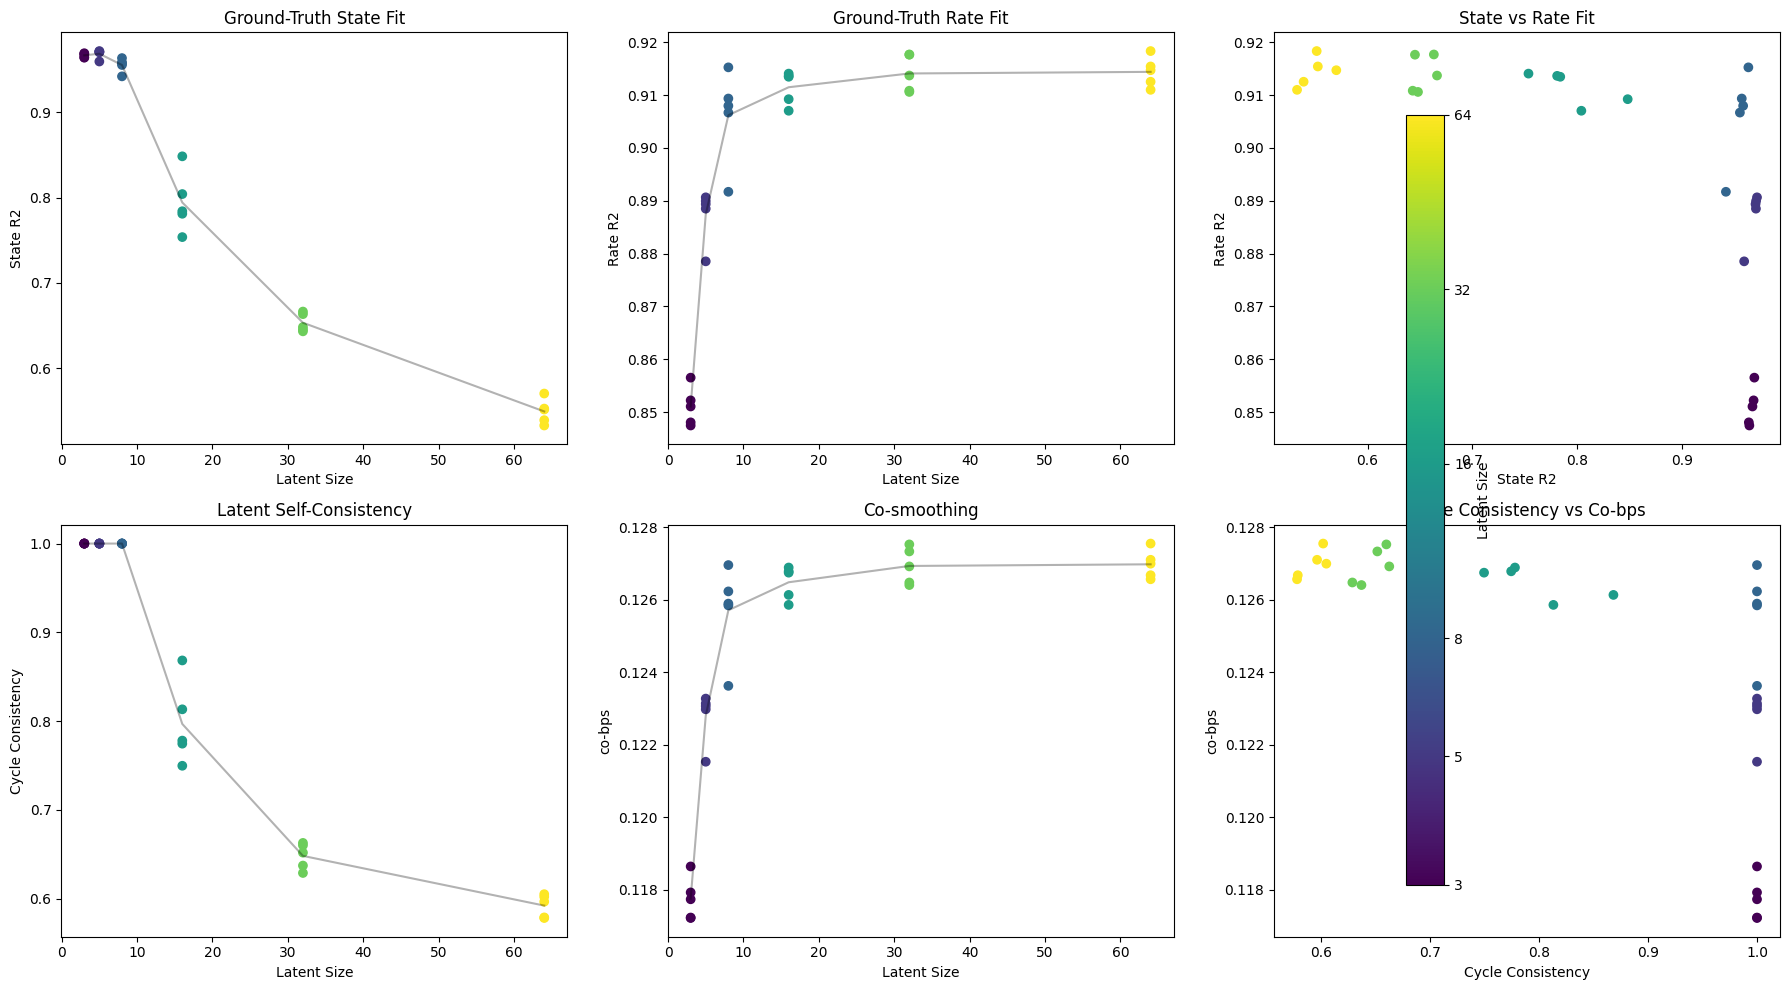

In [10]:
fig, ax = plt.subplots(2, 3, figsize=(18, 10))

scatter = ax[0, 0].scatter(lat_sizes, metrics["state_r2"], c=np.log10(lat_sizes))
ax[0, 0].plot(mean_metrics["state_r2"][:, 0], mean_metrics["state_r2"][:, 1], c="k", alpha=0.3)
ax[0, 0].set_xlabel("Latent Size")
ax[0, 0].set_ylabel("State R2")
ax[0, 0].set_title("Ground-Truth State Fit")

ax[0, 1].scatter(lat_sizes, metrics["rate_r2"], c=np.log10(lat_sizes))
ax[0, 1].plot(mean_metrics["rate_r2"][:, 0], mean_metrics["rate_r2"][:, 1], c="k", alpha=0.3)
ax[0, 1].set_xlabel("Latent Size")
ax[0, 1].set_ylabel("Rate R2")
ax[0, 1].set_title("Ground-Truth Rate Fit")

ax[0, 2].scatter(metrics["state_r2"], metrics["rate_r2"], c=np.log10(lat_sizes))
ax[0, 2].set_xlabel("State R2")
ax[0, 2].set_ylabel("Rate R2")
ax[0, 2].set_title("State vs Rate Fit")

ax[1, 0].scatter(lat_sizes, metrics["cycle_con"], c=np.log10(lat_sizes))
ax[1, 0].plot(mean_metrics["cycle_con"][:, 0], mean_metrics["cycle_con"][:, 1], c="k", alpha=0.3)
ax[1, 0].set_xlabel("Latent Size")
ax[1, 0].set_ylabel("Cycle Consistency")
ax[1, 0].set_title("Latent Self-Consistency")

ax[1, 1].scatter(lat_sizes, metrics["co-bps"], c=np.log10(lat_sizes))
ax[1, 1].plot(mean_metrics["co-bps"][:, 0], mean_metrics["co-bps"][:, 1], c="k", alpha=0.3)
ax[1, 1].set_xlabel("Latent Size")
ax[1, 1].set_ylabel("co-bps")
ax[1, 1].set_title("Co-smoothing")

ax[1, 2].scatter(metrics["cycle_con"], metrics["co-bps"], c=np.log10(lat_sizes))
ax[1, 2].set_xlabel("Cycle Consistency")
ax[1, 2].set_ylabel("co-bps")
ax[1, 2].set_title("Cycle Consistency vs Co-bps")

cbar = plt.colorbar(scatter, ax=ax.ravel().tolist())
cbar.set_label("Latent Size")
cbar.set_ticks(np.log10(np.unique(lat_sizes)))
cbar.set_ticklabels(np.unique(lat_sizes))

plt.tight_layout()
plt.show()


## Plot Geometry Metrics

These plots show the new TT-vs-DD geometry comparison metrics. Both are ground-truth-facing metrics, unlike `cycle_con`, which only inspects the inferred model internally.


/tmp/ipykernel_3904063/1191305379.py:35: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


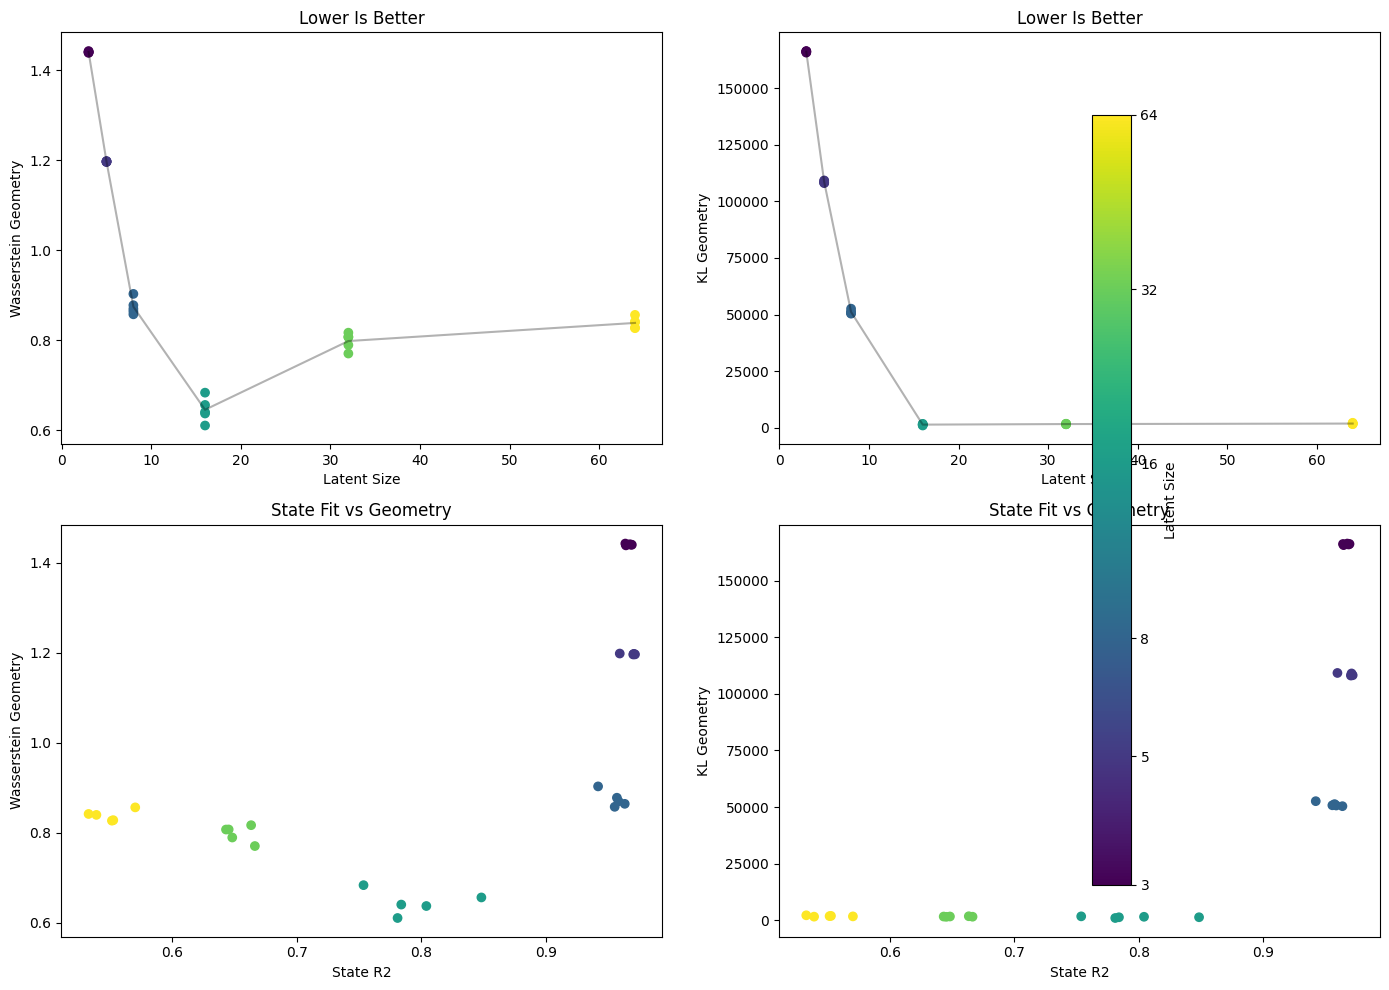

In [11]:
fig, ax = plt.subplots(2, 2, figsize=(14, 10))

scatter = ax[0, 0].scatter(lat_sizes, metrics["wasserstein_geometry"], c=np.log10(lat_sizes))
ax[0, 0].plot(
    mean_metrics["wasserstein_geometry"][:, 0],
    mean_metrics["wasserstein_geometry"][:, 1],
    c="k",
    alpha=0.3,
)
ax[0, 0].set_xlabel("Latent Size")
ax[0, 0].set_ylabel("Wasserstein Geometry")
ax[0, 0].set_title("Lower Is Better")

ax[0, 1].scatter(lat_sizes, metrics["kl_geometry"], c=np.log10(lat_sizes))
ax[0, 1].plot(mean_metrics["kl_geometry"][:, 0], mean_metrics["kl_geometry"][:, 1], c="k", alpha=0.3)
ax[0, 1].set_xlabel("Latent Size")
ax[0, 1].set_ylabel("KL Geometry")
ax[0, 1].set_title("Lower Is Better")

ax[1, 0].scatter(metrics["state_r2"], metrics["wasserstein_geometry"], c=np.log10(lat_sizes))
ax[1, 0].set_xlabel("State R2")
ax[1, 0].set_ylabel("Wasserstein Geometry")
ax[1, 0].set_title("State Fit vs Geometry")

ax[1, 1].scatter(metrics["state_r2"], metrics["kl_geometry"], c=np.log10(lat_sizes))
ax[1, 1].set_xlabel("State R2")
ax[1, 1].set_ylabel("KL Geometry")
ax[1, 1].set_title("State Fit vs Geometry")

cbar = plt.colorbar(scatter, ax=ax.ravel().tolist())
cbar.set_label("Latent Size")
cbar.set_ticks(np.log10(np.unique(lat_sizes)))
cbar.set_ticklabels(np.unique(lat_sizes))

plt.tight_layout()
plt.show()


## Compare Geometry Metrics Directly

Wasserstein and KL are not on the same numerical scale, but plotting them together is still useful for checking whether both metrics prefer similar model classes or latent sizes.


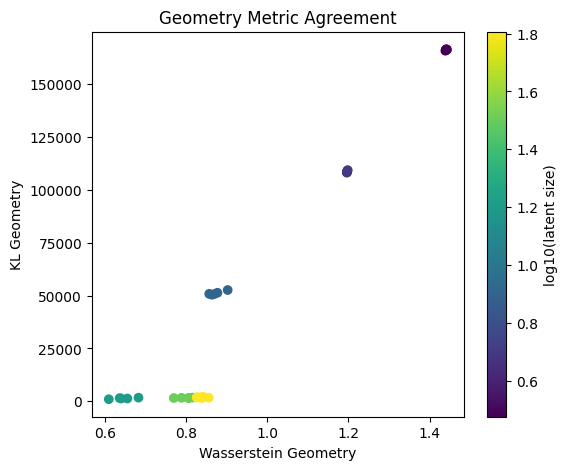

In [12]:
plt.figure(figsize=(6, 5))
plt.scatter(metrics["wasserstein_geometry"], metrics["kl_geometry"], c=np.log10(lat_sizes))
plt.xlabel("Wasserstein Geometry")
plt.ylabel("KL Geometry")
plt.title("Geometry Metric Agreement")
plt.colorbar(label="log10(latent size)")
plt.show()


## Optional: Plot TT Reference Trials

This is the same visual sanity-check used in the original notebook.


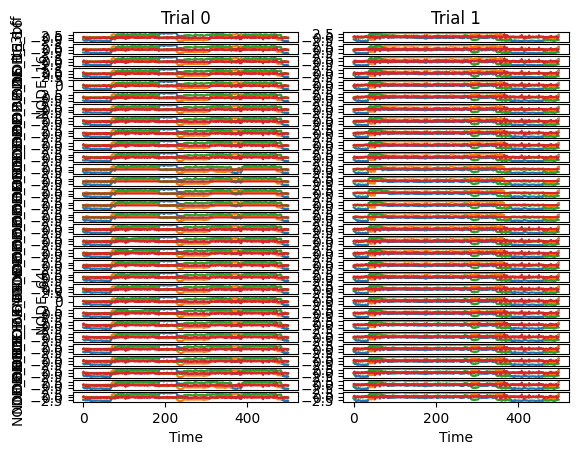

In [13]:
comparison.plot_trials_reference()
